# Introduction

Many quantities in probabilistic machine learning are expectations of the form

$$
\mathbb{E}_p[f(X)] = \int f(x)p(x),dx.
$$

When this integral cannot be evaluated analytically, sampling provides a practical way to approximate it.

This notebook introduces direct sampling, rejection sampling, importance sampling, Markov Chain Monte Carlo, gradient-based methods such as MALA and HMC, and basic MCMC diagnostics.

# Imports and Setup

In [1]:
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

warnings.filterwarnings('ignore')
sys.path.append(str(PROJECT_ROOT))

In [2]:
import time

import jax
import jax.numpy as jnp
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from jax import random

KEY = random.key(47)

In [3]:
cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    "owb", [(1, 1, 1), (255/255, 127/255, 14/255)], N = 1024
)

dw = matplotlib.colors.LinearSegmentedColormap.from_list(
    'wb', [[0.21568627, 0.25490196, 0.29019608], (1, 1, 1)], N = 1024
)

In [4]:
def plot_distribution(
        X1, 
        X2,
        Z,
        samples = None, 
        ax = None, 
        cmap = cmap, 
        levels = 30, 
        color = "C0", 
        vmin = None, 
        vmax = None, 
        title = None,
        label = "samples",
        s = None
):
    if ax is None:
        ax = plt.gca()

    contour = ax.contourf(
        X1,
        X2,
        Z,
        levels=levels,
        cmap=cmap,
        alpha=0.5,
        vmin=vmin,
        vmax=vmax,
    )

    if samples is not None:
        ax.scatter(
            samples[:, 0],
            samples[:, 1],
            color = color,
            cmap=cmap,
            s=s,
            edgecolor=[0.21568627, 0.25490196, 0.29019608],
            vmin=vmin,
            vmax=vmax,
            label=label,
        )

        ax.legend()

    if title is not None:
        ax.set_title(title)

    return contour

# Target Distributions

We will use two simple two-dimensional target distributions: a **Gaussian mixture** to study multimodality and a **banana-shaped distribution** to study nonlinear geometry.

## Gaussian Mixture: Multimodality

A Gaussian mixture distribution has density

$$ p(x) = \sum_{k=1}^{K} w_k\,\mathcal{N}(x;\mu_k,\Sigma_k), \quad \sum_{k=1}^{K} w_k = 1 $$

Separated mixture components provide a simple multimodal target and allow us to test whether a sampling method can move between different modes.

We will use four equally weighted components:
$$ w_k = \frac{1}{4} $$
with means
$$ \mu_1 = \begin{bmatrix} 2\\2 \end{bmatrix}, \quad \mu_2 = \begin{bmatrix} 2\\-2 \end{bmatrix}, \quad \mu_3 = \begin{bmatrix} -2\\2 \end{bmatrix}, \quad \mu_4 = \begin{bmatrix} -2\\-2 \end{bmatrix} $$
and identical covariance matrices
$$ \Sigma_k = 0.3 I $$

Thus,
$$ p(x) = \frac{1}{4} \sum_{k=1}^{4} \mathcal{N}(x; \mu_k, 0.3I) $$

In [5]:
def log_gaussian(x, mean, cov):
    x = jnp.atleast_2d(x)
    d = x.shape[-1]
    
    _, logdet = jnp.linalg.slogdet(cov)
    quad = jnp.einsum("ni,ij,nj->n", (x - mean), jnp.linalg.inv(cov), (x - mean))

    return -1/2 * (d * jnp.log(2 * jnp.pi) + logdet + quad)
    
def log_gmm(x, weights, means, covs):
    x = jnp.atleast_2d(x)
    
    weights = jnp.asarray(weights)
    weights = weights / jnp.sum(weights)
    
    means = jnp.asarray(means)
    covs = jnp.asarray(covs)

    def comp_logpdf(mean, cov, logw):
        return logw + log_gaussian(x, mean, cov)

    logw = jnp.log(weights)
    terms = jax.vmap(comp_logpdf)(means, covs, logw)

    return jax.scipy.special.logsumexp(terms, axis = 0)

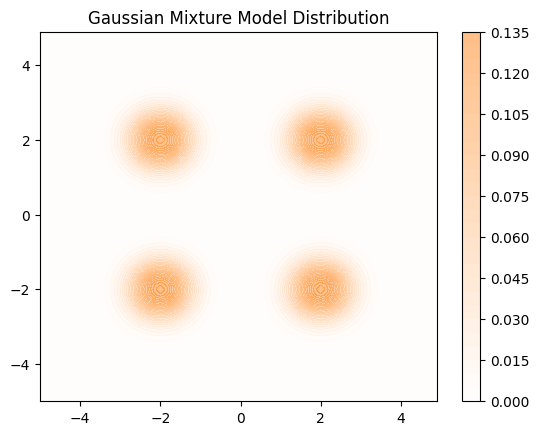

In [6]:
weights = jnp.array([1., 1., 1., 1.])
means = jnp.array([[-2., -2.], [-2., 2.], [2., -2.], [2., 2.]])
covs = jnp.array([0.3 * jnp.eye(2) for _ in range(len(weights))])

x1_grid_gmm = jnp.arange(-5, 5, 0.1)
x2_grid_gmm = jnp.arange(-5, 5, 0.1)

X1_gmm, X2_gmm = jnp.meshgrid(x1_grid_gmm, x2_grid_gmm)
X_grid_gmm = jnp.stack((X1_gmm.flatten(), X2_gmm.flatten()), axis = 1)

Z_gmm = jnp.exp(log_gmm(X_grid_gmm, weights = weights, 
                    means = means, 
                    covs = covs)).reshape(X1_gmm.shape)

contour = plot_distribution(X1_gmm, X2_gmm, Z_gmm, title = "Gaussian Mixture Model Distribution")
plt.colorbar(contour)

## Banana Distribution: Nonlinear Geometry

The banana distribution provides a simple target with strong nonlinear dependence and curved geometry, making it useful for comparing local and gradient-based sampling methods.

We construct it from independent Gaussian variables
$$ u \sim \mathcal{N}(0,\sigma_u^2), \quad v \sim \mathcal{N}(0,\sigma_v^2) $$
using the transformation
$$ x=u, \quad y=v+b(u^2-\sigma_u^2) $$

The resulting density is
$$ p(x,y) = \mathcal{N}(x;0,\sigma_u^2) \, \mathcal{N} \left( y-b(x^2-\sigma_u^2); 0, \sigma_v^2 \right) $$

We will use
$$ b=0.5, \quad \sigma_u=0.7, \quad \sigma_v=0.2, $$

giving
$$ p(x,y) = \mathcal{N}(x;0,0.49) \, \mathcal{N} \left( y-0.5(x^2-0.49); 0,0.04 \right) $$

In [7]:
def log_gaussian_1d(x, sigma):
    return -1/2 * jnp.log(2 * jnp.pi * sigma**2) - 1/2 * x**2 / sigma**2

def log_banana_1d(xy, b = 0.5, su = 0.7, sv = 0.2):
    x = xy[0]
    y = xy[1]

    v = y - b * (x**2 - su**2)

    return log_gaussian_1d(x, su) + log_gaussian_1d(v, sv)

log_banana = jax.vmap(log_banana_1d)

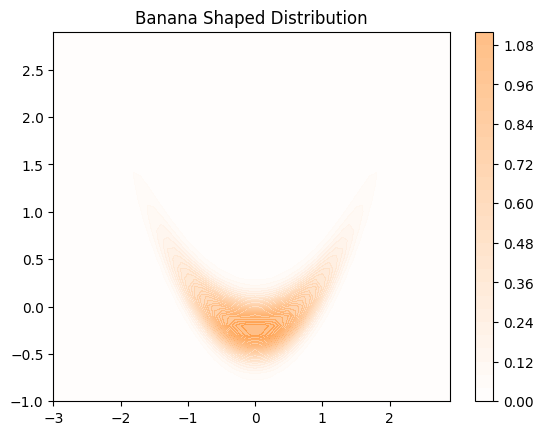

In [8]:
b = 0.5
su = 0.7
sv = 0.2

x1_banana = jnp.arange(-3, 3, 0.1)
x2_banana = jnp.arange(-1, 3, 0.1)

X1_banana, X2_banana = jnp.meshgrid(x1_banana, x2_banana)
X_grid_banana = jnp.stack((X1_banana.flatten(), X2_banana.flatten()), axis = 1)

Z_banana = jnp.exp(log_banana(X_grid_banana)).reshape(X1_banana.shape)

contour = plot_distribution(X1_banana, X2_banana, Z_banana, title = "Banana Shaped Distribution")
plt.colorbar(contour)

# Monte Carlo Estimation

Suppose we want to estimate some quantity
$$ I = \mathbb{E}_p \left[ f(X) \right] = \int f(x) p(x) dx $$
where 
$$ X \sim p $$
and $f$ is some arbitrary function.

This general form can be used to estimate such quantities as
* Mean: $f(x) = x$
* Variance: $f(x) = (x - \mathbb{E}_p[x])^2$
* Entropy: $f(x) = -\log p(x)$
* Marginal $p(y)$: $f(x) = p(y | x)$

Then, given samples
$$ x_1, x_2, \dots, x_N \sim p $$
we can estimate the expectation as
$$ \hat{I}_N \approx \frac{1}{N} \sum_{i=1}^n f(x_i) $$
by the Law of Large Numbers
$$ \hat{I}_N \to I \quad \text{as} \quad N \to \infty $$

Let us estimate the expectation of the squared norm of the random variable on our GMM:
$$ \mathbb{E} \left[ \| X \|^2 \right] \Rightarrow f(x) = \| x \|^2 $$
with
$$ X \sim \frac{1}{4} \sum_{k=1}^4 \mathcal{N} (\mu_k, 0.3I) $$

We have an analytical solution for the expectation
$$ \mathbb{E} \left[ \| X \|^2 \right] = \text{tr}(\Sigma) + \| \mu_k \|^2 $$
which is, in our case,
$$
\begin{aligned}
\mathbb{E} \left[ \| X \|^2 \right] &= \text{tr}(0.3I) + \| \mu_k \|^2 \\
&= 0.6 + 2^2 + 2^2 \\
&= 8.6
\end{aligned}
$$

## Variance and Standard Error

The estimator $\hat{I}_N$ is random, since our samples are random. The mean of the estimator is equal to $I$ itself, since Monte Carlo is an unbiased estimator. 

The variance of teh estimator is
$$ \text{Var}(\hat{I}_N) = \frac{\text{Var}_p(f(X))}{N} $$
then, the standard error is
$$ \text{SE}(\hat{I}_N) = \frac{\sigma_f}{\sqrt{N}} $$
where
$$ \sigma_f^2 = \text{Var}_p(f(X)) $$

We do not know $\sigma_f$ for sure, so let us estimate it from the samples:
$$ s_N^2 = \frac{1}{N-1} \sum_{i=1}^N (f(x_i) - \hat{I}_N)^2 $$

Then, the Standard Error of our estimator is
$$ \widehat{\text{SE}}(\hat{I}_n) = \frac{s_N}{\sqrt{N}} $$

Note that the standard error is inversely proportional to the square root of the number of samples, meaning that to halve the standard error, we need to increase the number of samples 4 times.

## Convergence Experiment

Text(0.5, 1.0, 'Standard Error of the Monte Carlo Estimation')

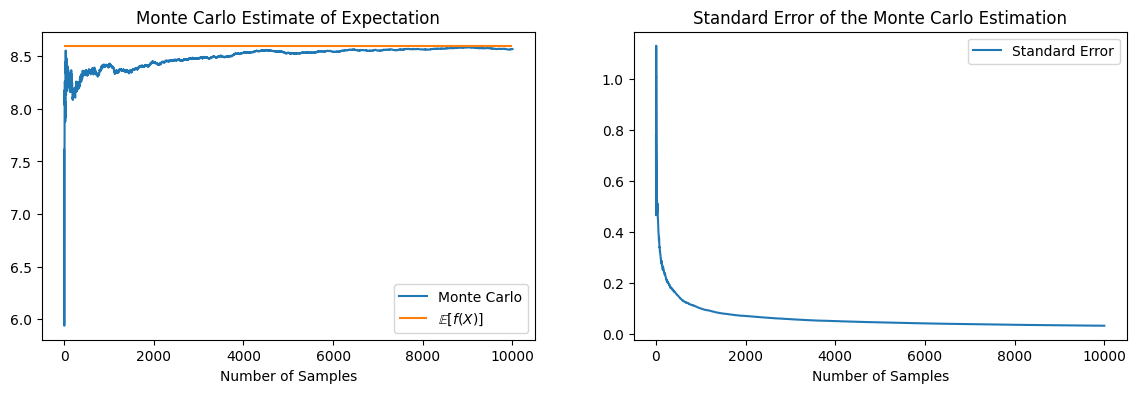

In [9]:
n_samples = 10_000

KEY, cat_key, normal_key = random.split(KEY, 3)

L = jnp.linalg.cholesky(covs)

cat_samples = random.categorical(cat_key, jnp.log(weights), shape = (n_samples, ))
normal_samples = random.normal(normal_key, shape = (n_samples, 2))
gmm_samples = means[cat_samples] + jnp.einsum(
    "bi,bij->bj",
    normal_samples,
    jnp.permute_dims(L[cat_samples], (0, 2, 1)),
)

f = jnp.sum(gmm_samples**2, axis = 1)
n = jnp.arange(1, n_samples + 1)

cum_f = jnp.cumsum(f)
cum_f2 = jnp.cumsum(f**2)

running_mean = cum_f / n

running_var = (
    cum_f2[1:] - cum_f[1:]**2 / n[1:]
) / (n[1:] - 1)

running_se = jnp.sqrt(running_var / n[1:])

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (14, 4))

axes[0].plot(n, running_mean, label = "Monte Carlo")
axes[0].hlines(8.6, 1, n_samples, label = r"$\mathbb{E}[f(X)]$", color = "C1")
axes[0].legend()
axes[0].set_xlabel("Number of Samples")
axes[0].set_title("Monte Carlo Estimate of Expectation")

axes[1].plot(n[1:], running_se, label = "Standard Error")
axes[1].legend()
axes[1].set_xlabel("Number of Samples")
axes[1].set_title("Standard Error of the Monte Carlo Estimation")

As can be seen, the Monte Carlo estimate converges to the analytical expectation we have calculated as well as the standard error converges to zero.

# Direct Sampling and Transformations

In this section we will discuss the easiest sampling techniques. If we have a relatively simple distribution we can directly sample from it. Two important examples are inverse transform sampling and transformations of random variables.

## Inverse Transform Sampling

Let us have a continuous distribution $X$ with a CDF $F$.

Then, if we have a uniform distribution
$$ U \sim \text{U}[0, 1] $$
we can simply claim that
$$ X = F^{-1}(U) $$
since
$$ \mathbb{P}(X \leq x) = \mathbb{P}(F^{-1}(U) \leq x) = \mathbb{P}(U \leq F(x)) = F(x) $$

For example, we want to sample from an exponential distribution
$$ X \sim \text{Exponential}(\lambda) $$

The CDF of an exponential distribution is
$$ F(x) = 1 - e^{-\lambda x} $$
then, setting
$$ u = 1 - e^{-\lambda x} $$
we can obtain the one-to-one mapping between $X$ and $U$. Inverting it:
$$ x = -\frac{1}{\lambda} \log (1 - u) $$
we can easily sample from $X$.

If
$$ u_1, u_2, \dots, u_N \sim \text{U}[0, 1] $$
we know that
$$ x_i = -\frac{1}{\lambda} \log (1 - u_i) \sim X = \text{Exponential}(\lambda) $$

Text(0.5, 1.0, 'Inverse Sampling vs Exponential PDF')

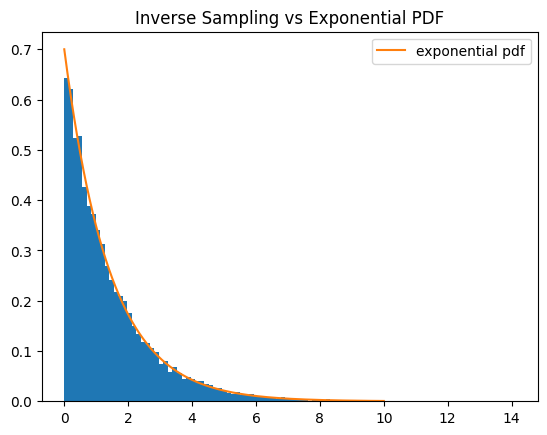

In [10]:
KEY, uniform_key = random.split(KEY, 2)

n_samples = 10_000
u_samples = random.uniform(uniform_key, (n_samples, ))

lbd = 0.7

x_samples = -1 / lbd * jnp.log(1 - u_samples)

x_grid = jnp.arange(0, 10.01, 0.01)
exp_pdf = jax.scipy.stats.expon.pdf(x_grid, scale = 1/lbd)

plt.hist(x_samples, density = True, bins = 100)
plt.plot(x_grid, exp_pdf, label = "exponential pdf")
plt.legend()
plt.title("Inverse Sampling vs Exponential PDF")

## Nonlinear Transformations

Another method is to apply a nonlinear transformation to a distribution that is easier to sample from. It can be seen a more generalized view on an inverse transformation considered in the last subsection. Let $Z$ be a distribution that is easy to sample from:
$$ Z \sim q(z) $$
and let $T$ be a transformation
$$ X = T(Z) $$
Then, using samples from $q$ we can obtain samples induced by $T$:
$$ z_i \sim q, \quad x_i = T(z_i) $$

Then, if $T$ is invertible we can use a change-of-variables to obtain the PDF of $X$
$$ p_X(x) = q(T^{-1}(x)) |\det J_{T^{-1}} (x)| $$

This transformation-based view also underlies methods such as normalizing flows, where the transformation itself is learned.

## Banana Example

As we have stated, for banana distribution
$$ u \sim \mathcal{N}(0, \sigma_u^2), \quad v \sim \mathcal{N}(0, \sigma_v^2) $$
and
$$ T \left( \begin{bmatrix} u \\ v \end{bmatrix} \right) = \begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix} u \\ v + b(u^2 - \sigma_u^2) \end{bmatrix} $$

### Inverse Transformation

Let us inverse this transformation
$$ T^{-1} \left( \begin{bmatrix} x \\ y \end{bmatrix} \right) = \begin{bmatrix} x \\ y - b(x^2 - \sigma_u^2) \end{bmatrix} $$

Then, the Jacobian is
$$ J_{T^{-1}} = \begin{bmatrix} 1 & 0 \\ -2bx & 1 \end{bmatrix} $$
so
$$ \det (J_{T^{-1}}) = 1 $$

Then, the distribution is
$$
\begin{aligned}
p \left( \begin{bmatrix} x \\ y \end{bmatrix} \right) &= q \left( T^{-1} \left( \begin{bmatrix} x \\ y \end{bmatrix} \right) \right) | \det (J_{T^{-1}}) | \\
&= \mathcal{N}(x;0,\sigma_u^2) \, \mathcal{N} \left( y-b(x^2-\sigma_u^2); 0, \sigma_v^2 \right)
\end{aligned}
$$

which is exactly the multivariate interpretation of the distribution we have stated before.

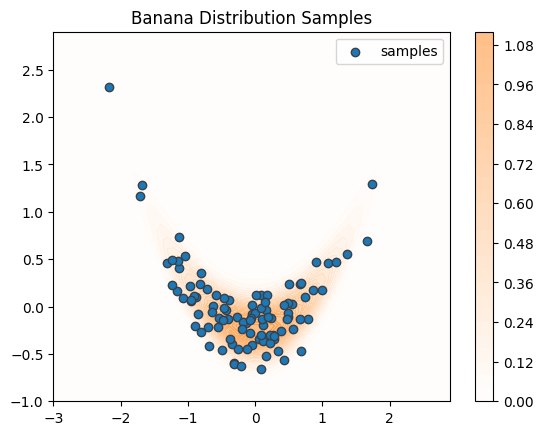

In [11]:
KEY, u_key, v_key = random.split(KEY, 3)

n_samples = 100

u = su * random.normal(u_key, shape=(n_samples,))
v = sv * random.normal(v_key, shape=(n_samples,))

x = u
y = v + b * (u**2 - 0.7**2)

banana_samples = jnp.stack([x, y], axis=1)

contour = plot_distribution(X1_banana, X2_banana, Z_banana, samples = banana_samples, title = "Banana Distribution Samples")
plt.colorbar(contour)

# Rejection Sampling

Rejection sampling generates independent samples from a target distribution $p(x)$ using an easier proposal distribution $q(x)$. Proposal samples are accepted with a probability determined by the ratio between the target and proposal densities.

## Algorithm

The algorithm is quite easy, let us have a proposed distribution $q(x)$ such that for all $x$:
$$ p(x) \leq Mq(x), \quad M \geq 1 $$

Then, the algorithm is as follows:
1. Sample $x \sim q(x)$
2. Sample $u \sim \text{U}(0, 1)$
3. Accept $x$ if
$$ u \leq \frac{p(x)}{Mq(x)} \Rightarrow \log u \leq \log p(x) - \log q(x) - \log M $$

The fraction above is called **acceptance probability**
$$ \boxed{\alpha(x) = \frac{p(x)}{Mq(x)}} $$

## Envelope and Acceptance Probability

The distribution
$$ Mq(x) $$
is called an **envelope**, for the algorithm to work we require it to dominate the target distribution.

The minimal valid $M$ is
$$ M^* = \sup_{x} \frac{p(x)}{q(x)} $$

Let us calculate the expected acceptance probability:
$$
\begin{aligned}
\mathbb{E} [\alpha (x)] &= \int q(x) \frac{p(x)}{Mq(x)} dx \\
&= \frac{1}{M} \int p(x) dx \\
&= \frac{1}{M}
\end{aligned}
$$
for normalized $p(x)$.

Then, the general acceptance probability is
$$ \mathbb{P}(\text{accept}) = \frac{1}{M} $$

So, a good envelope keeps $M$ small to increase the probability of accept while being dominant on $p(x)$.

## Gaussian Mixture Example

Let us see how the rejection sampling will tackle our Gaussian Mixture distribution. Let our proposal be a Gaussian centered at origin
$$ q(x) = \mathcal{N}(x; 0, \sigma_q^2 I) $$

Let us choose some arbitrary $\sigma_q$ for now.

M = 162.62
Acceptance rate: 0.01


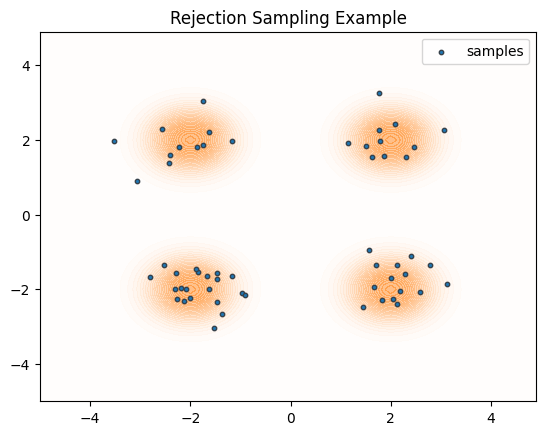

In [12]:
sigma_q = 1
n_samples = 10_000
KEY, normal_key, uniform_key = random.split(KEY, 3)

normal_samples = random.normal(normal_key, (n_samples, 2))
q_samples = normal_samples * sigma_q
u_samples = random.uniform(uniform_key, (n_samples, ))

log_q = log_gaussian(q_samples, mean = jnp.zeros(2), cov = sigma_q**2 * jnp.eye(2))
log_p = log_gmm(q_samples, weights = weights, means = means, covs = covs)

M = jnp.exp(jnp.max(log_p - log_q))

accept_mask = (jnp.log(u_samples) <= log_p - log_q - jnp.log(M))
accepted_samples = q_samples[accept_mask]

print(f"M = {M:.2f}")
print(f"Acceptance rate: {len(accepted_samples) / n_samples:.2f}")

plot_distribution(X1_gmm, X2_gmm, Z_gmm, samples = accepted_samples, title = "Rejection Sampling Example", s = 10)

In the example above we have used an arbitrary $\sigma_q=1$ and obtained a relatively small acceptance rate. Let us run a grid search over $(1, 10)$ and try to find a better envelope.

Optimal sigma_q: 2.18
Optimal M: 9.70
Optimal Acceptance Rate: 0.10


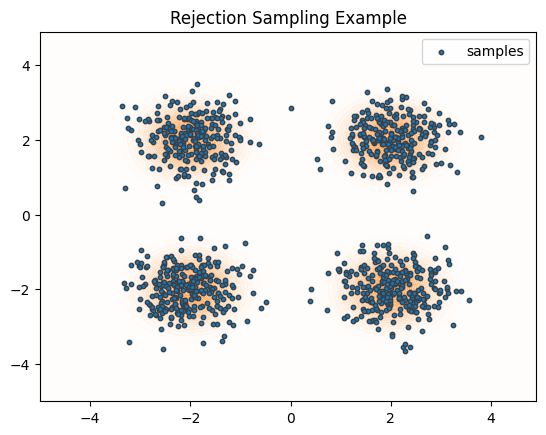

In [13]:
sigma_q_grid = jnp.linspace(1.0, 10.0, 100)

def minimal_M(sigma_q):
    q_samples = normal_samples * sigma_q

    log_q = log_gaussian(
        q_samples,
        mean = jnp.zeros(2),
        cov = sigma_q**2 * jnp.eye(2)
    )

    log_p = log_gmm(
        q_samples,
        weights = weights,
        means = means,
        covs = covs
    )

    M = jnp.exp(jnp.max(log_p - log_q))

    return M


M_values = jnp.array([
    minimal_M(sigma_q)
    for sigma_q in sigma_q_grid
])

best_idx = jnp.argmin(M_values)

sigma_q = sigma_q_grid[best_idx]
M = M_values[best_idx]

print(f"Optimal sigma_q: {sigma_q:.2f}")
print(f"Optimal M: {M:.2f}")
print(f"Optimal Acceptance Rate: {1 / M:.2f}")


q_samples = normal_samples * sigma_q

log_q = log_gaussian(
    q_samples,
    mean = jnp.zeros(2),
    cov = sigma_q**2 * jnp.eye(2)
)

log_p = log_gmm(
    q_samples,
    weights = weights,
    means = means,
    covs = covs
)

accept_mask = (
    jnp.log(u_samples)
    <= log_p - log_q - jnp.log(M)
)

accepted_samples = q_samples[accept_mask]

plot_distribution(
    X1_gmm,
    X2_gmm,
    Z_gmm,
    samples = accepted_samples,
    title = "Rejection Sampling Example",
    s = 10
)

Now we can see a much better acceptance rate.

# Importance Sampling

Importance sampling estimates expectations under a target distribution $p(x)$ using samples from an easier proposal distribution $q(x)$. Samples are weighted according to how much more likely they are under the target than under the proposal.

## Importance Weights

Let us have an integral of the form discussed before
$$ I = \mathbb{E}_p [f(X)] = \int f(x) p(x) dx $$
If we divide and multiply this integral by $q(x)$ we will have
$$ I = \int f(x) \frac{p(x)}{q(x)} q(x) = \mathbb{E}_q \left[ f(X) \frac{p(X)}{q(X)} \right] $$
Note that we have changed the expectation calculation from a target distribution $p$ to a proposal $q$. 

Let us sample
$$ x_i \sim q(x) $$
then, the ratio
$$ \frac{p(x_i)}{q(x_i)} $$
is usally called **importance weight**
and the estimate can be calculated by
$$ \hat{I}_N = \frac{1}{N} \sum_{i=1}^N f(x_i) w_i $$

In this notebook we are using log-space for the densities, so the weights will be calculated as
$$ \log w_i = \log p(x_i) - \log q(x_i) $$
and exponentiated later.

For this algorithm we require so called **suport conndition**
$$ p(x) > 0 \Rightarrow q(x) > 0 $$
otherwise the proposal can completely miss regions with target probability mass.

## Self-Normalized Importance Sampling

Most of the times we only know the target distribution up to a normalization constant
$$ p(x) = \frac{\tilde{p}(x)}{Z} $$
where $Z$ is unknown normalization constant.

The good thing about the importance sampling is that we can normalize weights without calculating $Z$. Let us have
$$ w_i = \frac{\tilde{p}(x_i)}{q(x_i)} $$
then, we can normalize them using
$$ \bar{w}_i = \frac{w_i}{\sum_j w_j} $$

And now we have an estimate
$$ \hat{I}_N^{\text{SNIS}} = \sum_{i=1}^N \bar{w}_i f(x_i) $$

Unlike the usual importance sampling, SNIS is biased, however it is pretty stable for large values of $N$.

## Effective Sample Size

The problem with SNIS is that we can technically have $N$ samples, but the weight of one of them is carrying almost all the total weight. In such case the estimator will be very biased towards that high-weight sample. 

Let us have a normalized weight distribution
$$ \sum_{i=1}^N \bar{w}_i = 1 $$
and define an Effective Sample Size
$$ \text{ESS} = \frac{1}{\sum_{i=1}^N \bar{w}_i^2} $$

Then, if we have equally important samples
$$ \bar{w}_i = \frac{1}{N} $$
the Effective Sample Size is
$$ \text{ESS} = \frac{1}{\sum_{i=1}^N \frac{1}{N^2}} = N $$
On contrary, if we have one sample with large weight
$$ \bar{w}_j \approx 1 $$
then, the ESS is
$$ \text{ESS} \approx \frac{1}{1} = 1 $$

So, the Effective Sample Size is approximating the number of samples that are actually important for the estimation.

It is also useful to calculate the **relative ESS**
$$ \frac{\text{ESS}}{N} \in [0, 1] $$

## Banana Example

Let us use an origin-centered Gaussian as a proposal distribution $q(x)$:
$$ q(x) = \mathcal{N}(x; 0, \sigma_q^2 I) $$
to estimate 
$$ \mathbb{E}_p(f(X)) $$
with
$$ f(x, y) = x^2 + y^2 $$

Recall the Banana shaped distribution
$$ p(x,y) = \mathcal{N}(x;0,\sigma_u^2) \, \mathcal{N} \left( y-b(x^2-\sigma_u^2); 0, \sigma_v^2 \right) $$

Then, since
$$ x = u, \quad y = v + b(u^2 - \sigma_u^2) $$
we have
$$ \mathbb{E}[x^2] = \sigma_u^2 $$
and
$$ \mathbb{E}[y^2] = \sigma_v^2 + b^2 \text{Var}(u^2) $$
with
$$ \text{Var}(u^2) = 2 \sigma_u^4 $$

Therefore,
$$ \mathbb{E}_p(x^2 + y^2) = \sigma_u^2 + \sigma_v^2 + 2 b^2 \sigma_u^4 \approx 0.65 $$

In [14]:
n_samples = 10_000
sigma_q = 2.
KEY, normal_key = random.split(KEY, 2)

normal_samples = random.normal(normal_key, (n_samples, 2))
q_samples = normal_samples * sigma_q

log_p = log_banana(q_samples)
log_q = log_gaussian(q_samples, mean = jnp.zeros(2), cov = sigma_q**2 * jnp.eye(2))
log_w = log_p - log_q

log_norm_w = log_w - jax.scipy.special.logsumexp(log_w)
norm_w = jnp.exp(log_norm_w)

estimator = jnp.sum(norm_w * jnp.sum(q_samples**2, axis = 1))

effective_sample_size = 1 / jnp.sum(norm_w**2)
relative_effective_sample_size = effective_sample_size / n_samples

print(f"Estimated Expectation: {estimator:.2f}")
print(f"ESS: {effective_sample_size}")
print(f"Relative ESS: {relative_effective_sample_size:.2f}")

Estimated Expectation: 0.64
ESS: 660.8467407226562
Relative ESS: 0.07


For this value of $\sigma_q = 2$ we have a relative ESS of 0.07, which means we are using roughly $7\%$ of our samples. Let us experiment with different values and see how the results will differ. 

In [15]:
for sigma_q in [0.3, 0.5, 1, 2, 5]:
    q_samples = normal_samples * sigma_q

    log_p = log_banana(q_samples)
    log_q = log_gaussian(q_samples, mean = jnp.zeros(2), cov = sigma_q**2 * jnp.eye(2))
    log_w = log_p - log_q

    log_norm_w = log_w - jax.scipy.special.logsumexp(log_w)
    norm_w = jnp.exp(log_norm_w)

    estimator = jnp.sum(norm_w * jnp.sum(q_samples**2, axis = 1))

    effective_sample_size = 1 / jnp.sum(norm_w**2)
    relative_effective_sample_size = effective_sample_size / n_samples

    print(f"sigma_q: {sigma_q}")
    print(f"Estimated Expectation: {estimator:.2f}")
    print(f"ESS: {effective_sample_size:.0f}")
    print(f"Relative ESS: {relative_effective_sample_size:.2f}")
    print()

sigma_q: 0.3
Estimated Expectation: 0.49
ESS: 53
Relative ESS: 0.01

sigma_q: 0.5
Estimated Expectation: 0.51
ESS: 3116
Relative ESS: 0.31

sigma_q: 1
Estimated Expectation: 0.69
ESS: 2331
Relative ESS: 0.23

sigma_q: 2
Estimated Expectation: 0.64
ESS: 661
Relative ESS: 0.07

sigma_q: 5
Estimated Expectation: 0.63
ESS: 110
Relative ESS: 0.01



The experiment shows that importance sampling works best when the proposal scale is reasonably matched to the target. Intermediate values, especially $\sigma_q=0.5$ and $\sigma_q=1$, give the highest ESS and estimates closest to the true expectation. When the proposal is too narrow or too broad, the weights become highly uneven, the effective sample size collapses, and the estimate becomes noticeably less reliable.


# Markov Chain Monte Carlo

Markov Chain Monte Carlo constructs a sequence of correlated samples whose long-run distribution is the desired target distribution. This allows expectations under $p(x)$ to be approximated even when direct independent sampling is unavailable.

## Markov Chains and Stationary Distributions

Let us have a Markov Chain of
$$ X_0, X_1, X_2, \dots $$
such that 
$$ p(x_{t+1} \mid x_{0:t}) = p(x_{t+1} \mid x_t) $$
which means that the probability of the next state depends only on current state.

Let, then, the transition kernel be
$$ K(x' \mid x) = p(X_{t+1} = x' \mid X_t = x) $$

A distribution $p$ is stationary for $K$ if
$$ p(x') = \int K(x' \mid x) p(x) dx $$
meaning
> If $X_t \sim p$, after one step we will still have $X_{t+1} \sim p$

For MCMC we construct $K$ so that the target distribution is stationary for $K$.

Then, under some assumptions:
$$ X_t \to p \quad \text{as} \quad t \to \infty $$

Note that the earlier states highly depend on initialization, but the later ones should, in theory, sample from $p$ as it is the stationary distribution. That is why one might consider discarding the earlier states (also called **warm-up period**).

## Why Correlated Samples Still Work

Note that Monte Carlo was using independent samples from $p$. However, Markov Chain Monte Carlo conditions the next state (sample) on the current one, thus, they are correlated. 

Nevertheless, for an ergodic Markov chain with stationary distribution $p$, the ergodic theorem gives
$$ \frac{1}{N} \sum_{t=1}^N f(X_t) \to \mathbb{E}_p [f(X)], \quad N \to \infty $$
so we can use the same Monte Carlo estimate
$$ \hat{I}_N^{\text{MCMC}} = \frac{1}{N} \sum_{t=1}^N f(X_t) $$
The important distinction, however, is the variance. As the samples are correlated, we have more variance in the estimator. Thus, the effective sample size will also be smaller. This effect will be quantified later in the notebook.

# Metropolis-Hastings

Metropolis-Hastings constructs a Markov chain by proposing a new state and accepting or rejecting it using a probability chosen so that the target distribution is stationary.

## General MH Algorithm

Suppose we have a Markov Chain and currently we are on a state
$$ x_t $$
Then, we propose the next state using the current state and a proposal distribution
$$ x' \sim q(x' \mid x_t) $$
We accept the proposed state with probability
$$ \alpha(x_t, x') = \min \left( 1, \frac{p(x') q(x_t \mid x')}{p(x_t) q(x' \mid x_t)} \right) $$
and assign the next state as $x_{t+1} = x'$ if we accept it, otherwise we stay $x_{t+1}=x_t$ 
$$ x_{t+1} = \begin{cases} x' & \text{w.p. } \alpha(x_t, x') \\ x_t & \text{otherwise} \end{cases} $$
In the acceptance probability formula one can understand the ratio as
* $p(x') / p(x_t)$ prefers moves to a higher target density:
    * if $p(x') > p(x_t)$, the $x'$ has higher density than $x_t$ in the target distribution
* $q(x_t \mid x') / q(x' \mid x_t)$ corrects the acceptance probability for assymetric proposals

Note that MH does not require for the target to be normalized as the normalization constant cancels out
$$ p(x) = \frac{\tilde{p}(x)}{Z} \Rightarrow \frac{\tilde{p}(x')}{\tilde{p}(x_t)} = \frac{p(x')}{p(x_t)} $$

In this notebook we will consider the logarithmic form of both distributions, so the acceptance rate is
$$ \log \alpha = \min (0, \log p(x') - \log p(x_t) + \log q(x_t \mid x') - \log q(x' \mid x_t)) $$
and we accept the proposal if
$$ \log u_t < \log \alpha, \quad u_t \sim \text{U}[0, 1] $$

Also note that if the proposal distribution $q(x' \mid x_t)$ is symmetric,
$$ q(x' \mid x_t) = q(x_t \mid x') \Rightarrow \log \alpha = \min (0, \log p(x') - \log p(x_t)) $$

## Random-Walk Metropolis

Let us consider the simplest example of the proposal distribution
$$ x' = x_t + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, \sigma_{\varepsilon}^2 I) $$

Then, the proposal distribution is
$$ q(x' \mid x_t) = \mathcal{N}(x'; x_t, \sigma_{\varepsilon}^2 I) $$

The psoposal is symmetric, so the log-acceptance probability is
$$ \log \alpha = \min (0, \log p(x') - \log p(x_t)) $$

Random-walk Metropolis explores the target using local perturbations around the current state.

## GMM Example

Let us start with a quite small $\sigma_{\varepsilon}$ and starting point $x_0$ at origin.

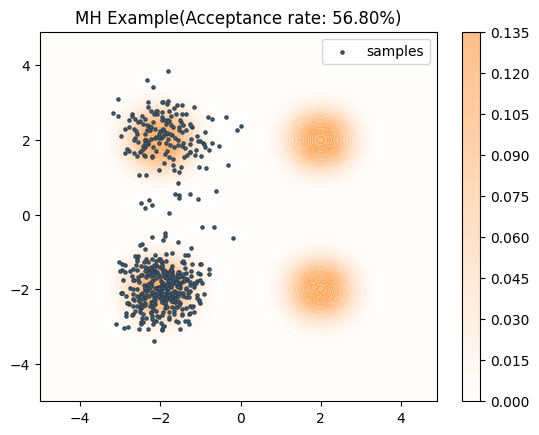

In [16]:
n_samples = 1000
sigma_eps = 0.5
KEY, normal_key, uniform_key = random.split(KEY, 3)

normal_samples = random.normal(normal_key, (n_samples, 2))
u_samples = random.uniform(uniform_key, (n_samples, ))

accepted_samples = []

x_cur = jnp.array([[0., 0.]])
for i in range(n_samples):
    x_prop = x_cur + normal_samples[i] * sigma_eps

    log_p = log_gmm(x_prop, weights = weights, means = means, covs = covs)
    log_q = log_gmm(x_cur, weights = weights, means = means, covs = covs)

    log_alpha = jnp.minimum(0, log_p - log_q)
    if jnp.log(u_samples[i]) < log_alpha:
        accepted_samples.append(x_prop)
        x_cur = x_prop

contour = plot_distribution(X1_gmm, X2_gmm, Z_gmm, 
                            samples = jnp.array(accepted_samples).squeeze(-2),  s = 5,
                            title = f"MH Example(Acceptance rate: {len(accepted_samples) / n_samples:.2%})")
plt.colorbar(contour)

As can be seen, MH covered only one mode very well, and did not sample anything from the other three. However, the acceptance rate is quite good.

Now let us experiment with different noise variances.

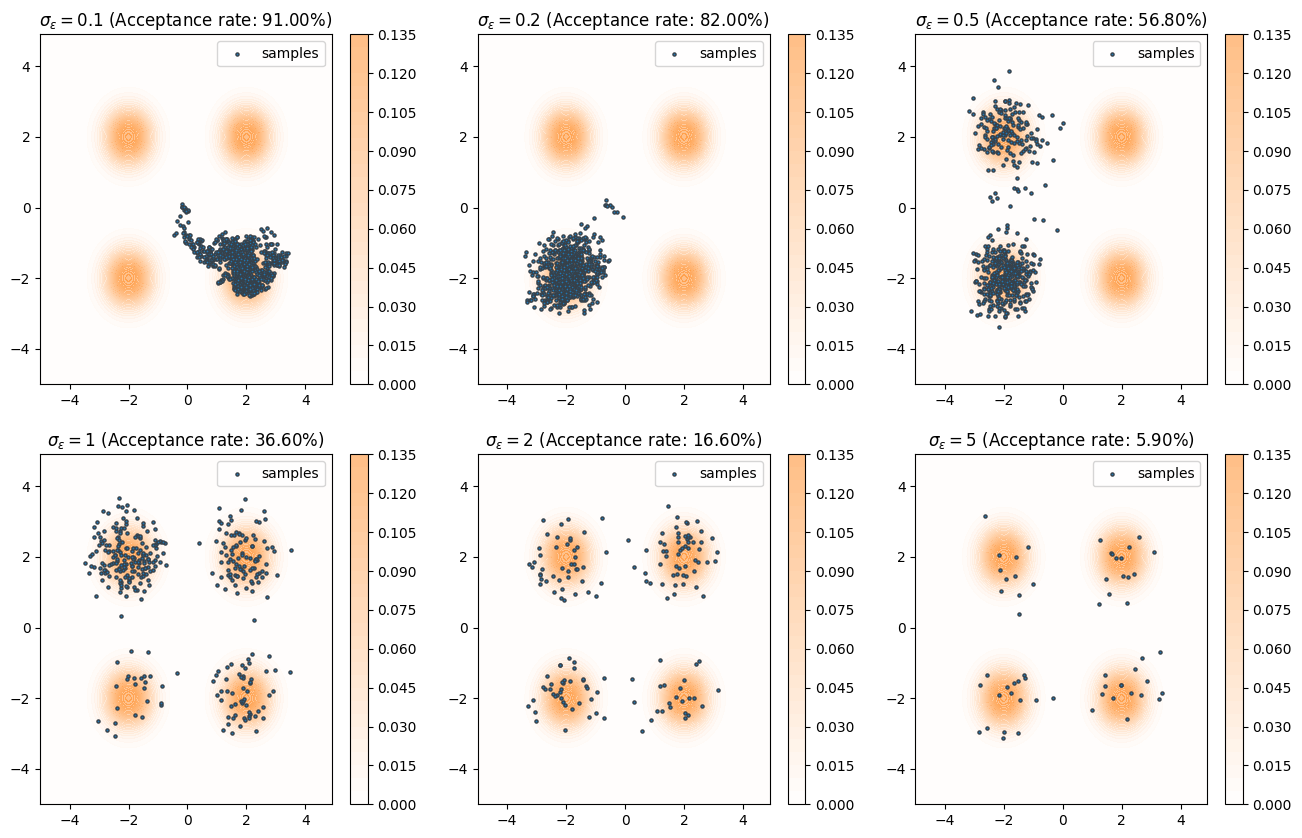

In [17]:
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (16, 10))
ax = axes.flatten()

for j, sigma_eps in enumerate([0.1, 0.2, 0.5, 1, 2, 5]):
    accepted_samples = []

    x_cur = jnp.array([0., 0.])
    for i in range(n_samples):
        x_prop = x_cur + normal_samples[i] * sigma_eps

        log_p_prop = log_gmm(x_prop, weights = weights, means = means, covs = covs)
        log_p_cur = log_gmm(x_cur, weights = weights, means = means, covs = covs)

        log_alpha = jnp.minimum(0, log_p_prop - log_p_cur)
        if jnp.log(u_samples[i]) < log_alpha:
            accepted_samples.append(x_prop)
            x_cur = x_prop

    contour = plot_distribution(X1_gmm, X2_gmm, Z_gmm, 
                                samples = jnp.array(accepted_samples),  s = 5,
                                title = fr"$\sigma_{{\varepsilon}} = {sigma_eps}$ (Acceptance rate: {len(accepted_samples) / n_samples:.2%})",
                                ax = ax[j])
    fig.colorbar(contour, ax = ax[j])

As the proposal scale increases, the chain moves more easily between the four modes, but the acceptance rate decreases. Small values such as $\sigma_\varepsilon=0.1$ or $0.2$ have high acceptance rates but remain trapped in a single mode, while intermediate values around $\sigma_\varepsilon=0.5$ to $1$ achieve much better global exploration. Very large steps still cover all modes, but most proposals are rejected, making the chain inefficient.

## Local vs Global Proposals

As one could see in the previous section the local proposal had a very big chance of getting stuck in one mode given the multimodal target distribution. This could be tackled by increasing the covariance of the proposal distribution, with the tradeoff between mode coverage and acceptance rate.

In this section let us see how the global proposal not dependent on the current state can be used to tackle this problem.

Let the proposal be
$$ q(x' \mid x_t) = q(x') = \mathcal{N}(x'; 0, \sigma_{q}^2 I) $$

with different values of $\sigma_q$.

Since the proposed distribution is not symmetric:
$$ \mathcal{N}(x'; 0, \sigma_{q}^2 I) \neq \mathcal{N}(x_t; 0, \sigma_{q}^2 I) $$
so we need to use full acceptance probability formula.

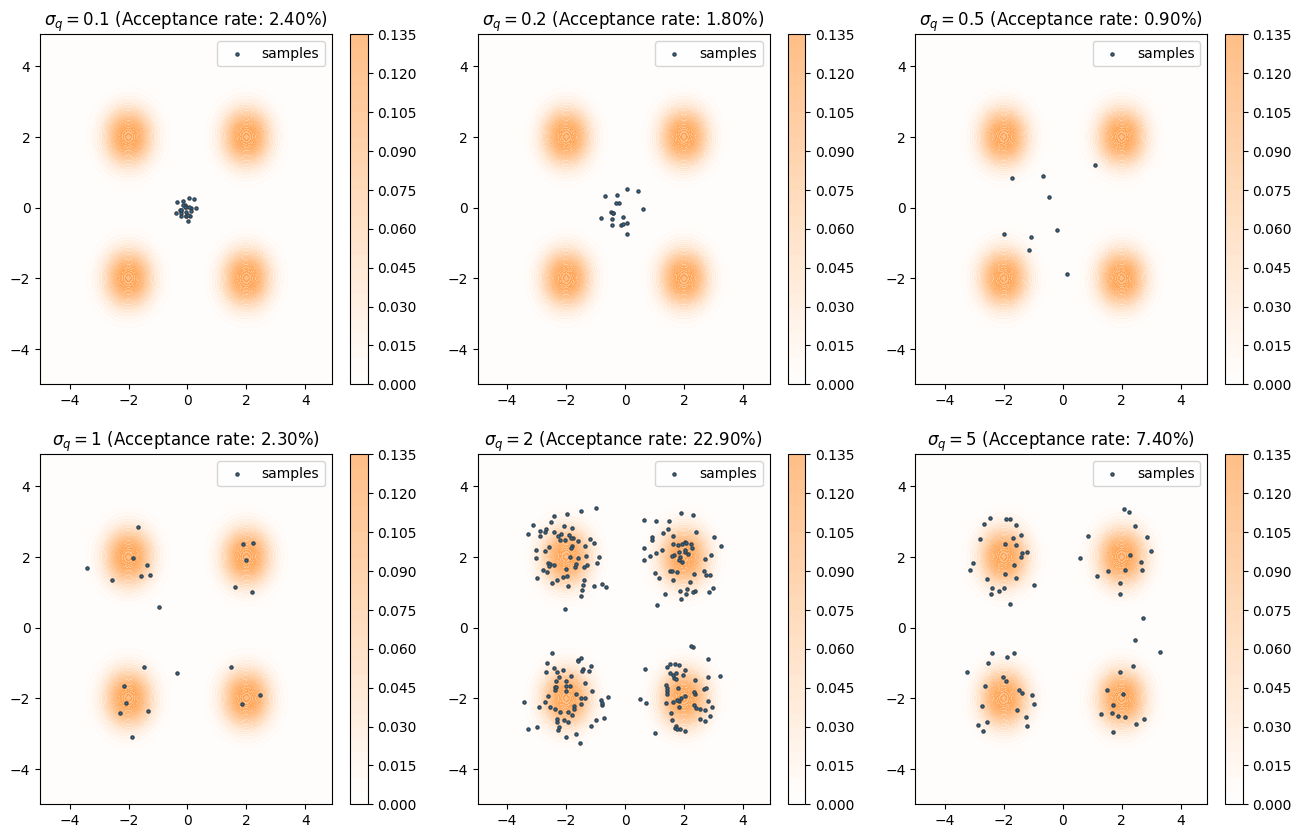

In [18]:
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (16, 10))
ax = axes.flatten()

for j, sigma_q in enumerate([0.1, 0.2, 0.5, 1, 2, 5]):
    accepted_samples = []

    x_cur = jnp.array([0., 0.])
    for i in range(n_samples):
        x_prop = normal_samples[i] * sigma_q

        log_p_prop = log_gmm(x_prop, weights = weights, means = means, covs = covs)
        log_p_cur = log_gmm(x_cur, weights = weights, means = means, covs = covs)

        log_q_prop = log_gaussian(x_prop, mean = jnp.zeros(2), cov = sigma_q**2 * jnp.eye(2))
        log_q_cur = log_gaussian(x_cur, mean = jnp.zeros(2), cov = sigma_q**2 * jnp.eye(2))

        log_alpha = jnp.minimum(0, log_p_prop - log_p_cur + log_q_cur - log_q_prop)
        if jnp.log(u_samples[i]) < log_alpha:
            accepted_samples.append(x_prop)
            x_cur = x_prop

    contour = plot_distribution(X1_gmm, X2_gmm, Z_gmm, 
                                samples = jnp.array(accepted_samples),  s = 5,
                                title = fr"$\sigma_q = {sigma_q}$ (Acceptance rate: {len(accepted_samples) / n_samples:.2%})",
                                ax = ax[j])
    fig.colorbar(contour, ax = ax[j])

The global proposal performs poorly when its scale is too small, since most proposals remain near the origin and rarely reach the target modes. Increasing the scale improves mode coverage, with $\sigma_q=2$ providing the best balance between exploration and acceptance in this experiment. When the proposal becomes too broad, as for $\sigma_q=5$, more samples are proposed in low-density regions and the acceptance rate decreases. Thus, global proposals can improve movement between modes, but their efficiency still strongly depends on matching the overall scale of the target.

# MCMC Diagnostics

MCMC samples are correlated and may fail to explore the entire target distribution. Diagnostics help assess mixing, sampling efficiency, and whether the chain adequately represents the target.

## Trace Plots

Let us examine how do trace plots of $x_{t, 0}$ and $x_{t, 1}$ look. Let us compare them using local random-walk MH discussed before with $\sigma_{\varepsilon} \in \{ 0.2, 1 \}$

In the visualizations above we have stored only samples acceted by MH. Here it will be better to use the entire chain
$$ x_0 \to x_1 \to x_2 \to \dots $$

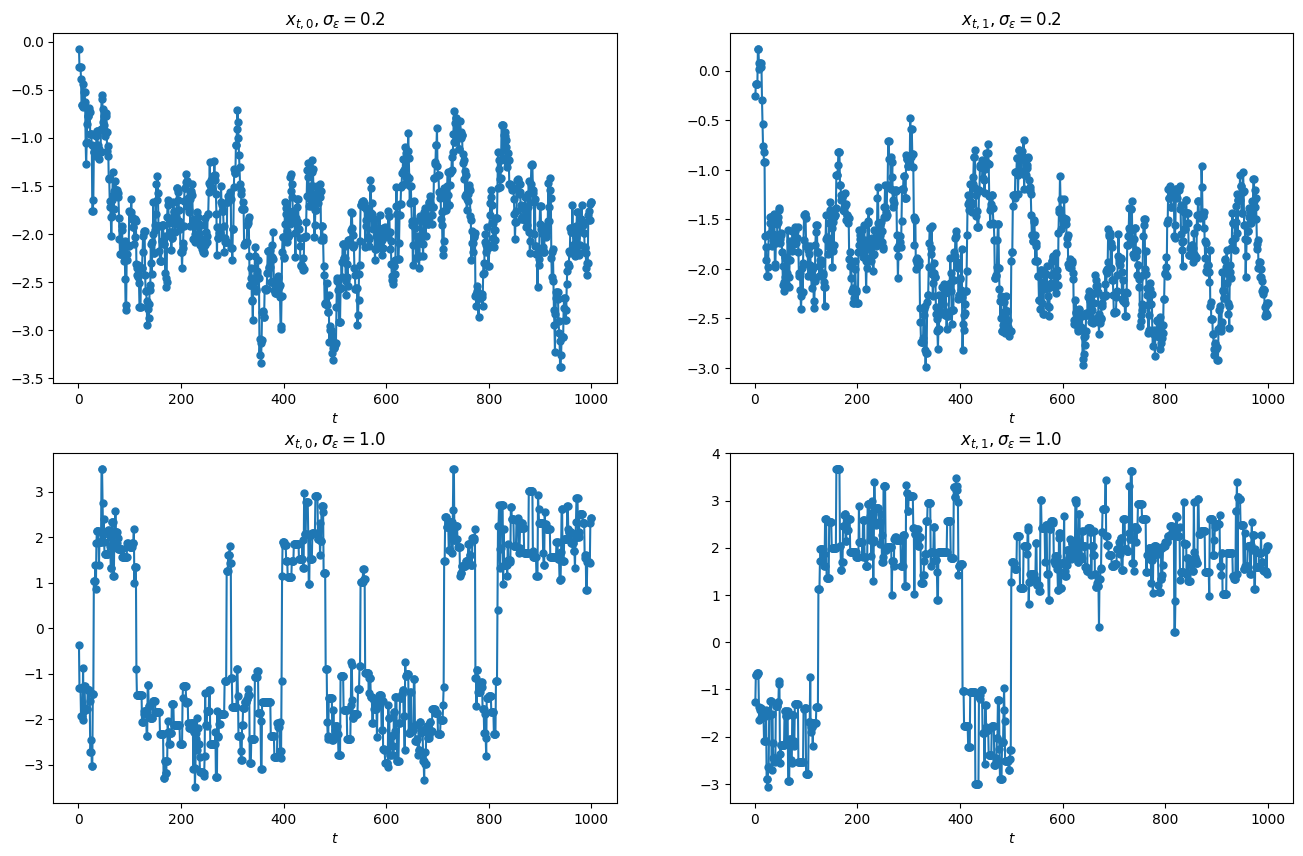

In [19]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (16, 10))
ax = axes.flatten()

for j, sigma_eps in enumerate([0.2, 1.0]):
    states_chain = []

    x_cur = jnp.array([0., 0.])
    for i in range(n_samples):
        x_prop = x_cur + normal_samples[i] * sigma_eps

        log_p_prop = log_gmm(x_prop, weights = weights, means = means, covs = covs)
        log_p_cur = log_gmm(x_cur, weights = weights, means = means, covs = covs)

        log_alpha = jnp.minimum(0, log_p_prop - log_p_cur)
        if jnp.log(u_samples[i]) < log_alpha:
            x_cur = x_prop

        states_chain.append(x_cur)

    for i in range(2):
        ax[2 * j + i].plot(jnp.arange(1, len(states_chain) + 1), jnp.array(states_chain)[:, i], "o-", markersize = 5)
        ax[2 * j + i].set_xlabel(r"$t$")
        ax[2 * j + i].set_title(fr"$x_{{t, {i}}}, \sigma_{{\varepsilon}} = {sigma_eps}$")

The graph shows
* Top row, $\sigma_{\varepsilon} = 0.2$:

    both coordinates stay mostly around positive values, roughly near $2$.
    
    So the chain is mostly exploring one mode and not switching much.
* Bottom row, $\sigma_{\varepsilon} = 1.0$:

    both coordinates jump between values near $2$ and $-2$.

    That means the chain is switching between modes, which is much better for this GMM.

## Autocorrelation

Since the samples are now correlated, we can measure the autocorrelation of the process with lag $k$:
$$ \rho_k = \text{Corr}(X_t, X_{t+k}) $$
empirically,
$$ \hat{\rho}_k = \frac{\sum_{t=1}^{N-k} (x_t - \bar{x}) (x_{t+k} - \bar{x})}{\sum_{t=1}^{N} (x_t - \bar{x})^2} $$

The autocorrelation can be interpreted as
* $\hat{\rho}_k \approx 1$ means that the samples are very highly correlated with lag $k$
* $\hat{\rho}_k \approx 0$ means that the dependence is almost gone

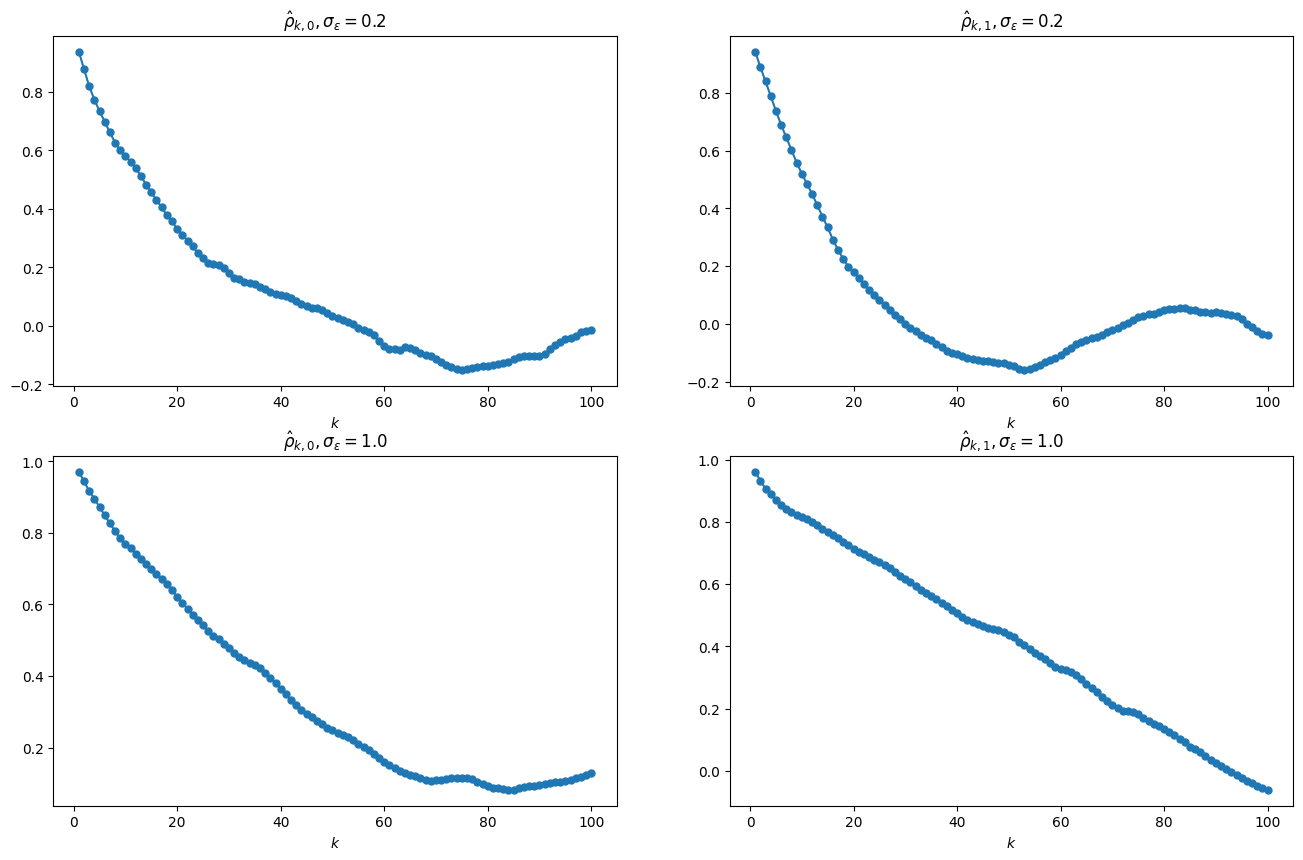

In [20]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (16, 10))
ax = axes.flatten()

for j, sigma_eps in enumerate([0.2, 1.0]):
    states_chain = []

    x_cur = jnp.array([0., 0.])
    for i in range(n_samples):
        x_prop = x_cur + normal_samples[i] * sigma_eps

        log_p_prop = log_gmm(x_prop, weights = weights, means = means, covs = covs)
        log_p_cur = log_gmm(x_cur, weights = weights, means = means, covs = covs)

        log_alpha = jnp.minimum(0, log_p_prop - log_p_cur)
        if jnp.log(u_samples[i]) < log_alpha:
            x_cur = x_prop

        states_chain.append(x_cur)

    states_chain = jnp.array(states_chain)

    states_mean = jnp.mean(states_chain, axis=0)
    l2_squared = jnp.sum(
        (states_chain - states_mean)**2,
        axis=0
    )

    acf = jnp.array([
        jnp.sum(
            (states_chain[:-k] - states_mean)
            * (states_chain[k:] - states_mean),
            axis=0
        ) / l2_squared
        for k in range(1, 101)
    ])

    for i in range(2):
        ax[2 * j + i].plot(jnp.arange(1, len(acf) + 1), acf[:, i], "o-", markersize = 5)
        ax[2 * j + i].set_xlabel(r"$k$")
        ax[2 * j + i].set_title(fr"$\hat{{\rho}}_{{k, {i}}}, \sigma_{{\varepsilon}} = {sigma_eps}$")

For $\sigma_\varepsilon=0.2$, autocorrelation decays relatively quickly despite the high acceptance rate ($83.9\%$). However, the coverage plot shows that the chain remains trapped in a single mode. Thus, the low long-lag autocorrelation only reflects reasonably good within-mode mixing, not successful exploration of the full target. In contrast, $\sigma_\varepsilon=1.0$ has a lower acceptance rate ($33.0\%$) and substantially stronger long-range autocorrelation, but explores all four modes. The persistent correlation arises partly because the chain spends consecutive iterations within the same mode before switching to another.

## Effective Sample Size \& Acceptance

For an independent Monte Carlo, $N$ samples mean $N$ pieces of independent informaion, thus, the Effective Sample Size is equal to the sample size.

For the MCMC, however, the samples are correlated, thus, Effective Sample Size is naturally smaller than the number of samples. Let us define the integrated autocorrelation time
$$ \tau = 1 + 2\sum_{k=1}^{\infty} \rho_k $$
Then,
$$ \text{ESS} \approx \frac{N}{\tau} $$
Meaning that strong autocorrelation reduces the effective number of independent samples represented by the chain. Let us again see how the relative ESS changes over the number of samples in MCMC.
$$ \text{Relative ESS} = \frac{\text{ESS}}{N} \approx \frac{1}{\tau} $$

In [21]:
def ess(states_chain, max_lag = 100):
    states_chain = jnp.asarray(states_chain)

    n_samples = states_chain.shape[0]

    states_mean = jnp.mean(states_chain, axis = 0)

    l2_squared = jnp.sum(
        (states_chain - states_mean)**2,
        axis = 0
    )

    acf = jnp.asarray([
        jnp.sum(
            (states_chain[:-k] - states_mean)
            * (states_chain[k:] - states_mean),
            axis = 0
        ) / l2_squared
        for k in range(1, min(max_lag, n_samples - 1) + 1)
    ])

    tau = []

    for j in range(states_chain.shape[1]):
        acf_sum = 0.

        for k in range(0, acf.shape[0] - 1, 2):
            pair_sum = acf[k, j] + acf[k + 1, j]

            if pair_sum <= 0:
                break

            acf_sum += pair_sum

        tau.append(1 + 2 * acf_sum)

    tau = jnp.asarray(tau)

    ess = n_samples / tau
    relative_ess = ess / n_samples

    return ess, relative_ess

In [22]:
results = []

for j, sigma_eps in enumerate([0.1, 0.2, 0.5, 1, 2, 5]):
    full_chain = []
    num_accepted = 0

    x_cur = jnp.array([0., 0.])
    for i in range(n_samples):
        x_prop = x_cur + normal_samples[i] * sigma_eps

        log_p_prop = log_gmm(x_prop, weights = weights, means = means, covs = covs)
        log_p_cur = log_gmm(x_cur, weights = weights, means = means, covs = covs)

        log_alpha = jnp.minimum(0, log_p_prop - log_p_cur)
        if jnp.log(u_samples[i]) < log_alpha:
            x_cur = x_prop
            num_accepted += 1

        full_chain.append(x_cur)

    full_chain = jnp.array(full_chain)

    ess_values, relative_ess = ess(full_chain)

    results.append({
        "sigma_eps": sigma_eps,
        "Acceptance (%)": num_accepted / n_samples,
        "Relative ESS_x0": relative_ess[0],
        "Relative ESS_x1": relative_ess[0],
    })

df = pd.DataFrame(results)
df.style.format({
    "sigma_eps": "{:.1f}",
    "Acceptance (%)": "{:.2%}",
    "Relative ESS_x0": "{:.2f}",
    "Relative ESS_x1": "{:.2f}",
})

,sigma_eps,Acceptance (%),Relative ESS_x0,Relative ESS_x1
0,0.1,91.00%,0.01,0.01
1,0.2,82.00%,0.03,0.03
2,0.5,56.80%,0.12,0.12
3,1.0,36.60%,0.01,0.01
4,2.0,16.60%,0.03,0.03
5,5.0,5.90%,0.02,0.02


The results show that very small proposal scales have high acceptance rates but extremely low ESS because consecutive samples are strongly correlated. Increasing the scale to $\sigma_\varepsilon=0.5$ gives the highest relative ESS, despite a lower acceptance rate, showing that moderate proposal steps produce more informative samples. For larger scales, frequent rejections again reduce ESS.

However, $\sigma_\varepsilon=0.5$ should not automatically be considered the best sampler: the previous coverage plots show that it can still remain trapped in a single mode. Thus, **acceptance rate and ESS measure sampling efficiency, but must be considered together with global mode coverage for multimodal targets.**

## Mode Coverage

Now let us examine the mode coverage for our GMM. The general coverage can be visually seen from the plots from the previous section where we have tested different $\sigma_{\varepsilon}$ values for MH.

In this section let us quantify the coverage of the mode as the ratio of the samples taken from each of the modes. The sample will be considered as belonging to a particular mode by calculating the distance from each of the modes
$$ c(x) = \arg \min_k \| x - \mu_k \| $$

Then, the total ratio of the samples belonging to the modes will be calculated
$$ \hat{w}_k = \frac{1}{N} \sum_{t=1}^N \mathbb{I}(c(x_t) = k) $$

In [23]:
results = {
    "Mode": [1, 2, 3, 4],
    "Target weight (%)": [25, 25, 25, 25],
}

for j, sigma_eps in enumerate([0.1, 0.2, 0.5, 1, 2, 5]):
    full_chain = []

    x_cur = jnp.array([0., 0.])
    for i in range(n_samples):
        x_prop = x_cur + normal_samples[i] * sigma_eps

        log_p_prop = log_gmm(x_prop, weights = weights, means = means, covs = covs)
        log_p_cur = log_gmm(x_cur, weights = weights, means = means, covs = covs)

        log_alpha = jnp.minimum(0, log_p_prop - log_p_cur)
        if jnp.log(u_samples[i]) < log_alpha:
            x_cur = x_prop

        full_chain.append(x_cur)

    full_chain = jnp.array(full_chain)

    distances = jnp.linalg.norm(full_chain[:, None, :] - means[None, :, :], axis = 2)
    classes = jnp.argmin(distances, axis = 1)

    values, counts = jnp.unique_counts(classes)
    counts = jnp.bincount(
        classes,
        length=4,
    )

    rates = counts / counts.sum()

    results[fr"sigma_eps={sigma_eps}"] = rates * 100

df = pd.DataFrame(results)
df.style.format({
    "Target weight (%)": "{:.1f}",
    **{
        f"sigma_eps={sigma_eps}": "{:.1f}"
        for sigma_eps in [0.1, 0.2, 0.5, 1, 2, 5]
    },
})

,Mode,Target weight (%),sigma_eps=0.1,sigma_eps=0.2,sigma_eps=0.5,sigma_eps=1,sigma_eps=2,sigma_eps=5
0,1,25.0,2.5,99.2,68.4,5.8,19.8,43.0
1,2,25.0,0.5,0.8,31.5,51.1,33.6,7.3
2,3,25.0,97.0,0.0,0.0,16.0,13.3,29.0
3,4,25.0,0.0,0.0,0.1,27.1,33.3,20.7


Mode coverage strongly depends on the proposal scale. For $\sigma_\varepsilon\le 0.5$, the chain is effectively trapped in a single mode, despite relatively good acceptance and ESS at $\sigma_\varepsilon=0.5$. At $\sigma_\varepsilon=1$, the chain reaches all modes but still samples them very unevenly. Larger scales, especially $\sigma_\varepsilon=2$ and $5$, provide much more balanced coverage, with empirical frequencies approaching the target $25\%$ per mode.

This confirms that for multimodal targets, **good ESS or acceptance alone is not enough; global mode coverage must also be checked.**


# Metropolis-Adjusted Langevin Algorithm

MALA combines gradient information from the target density with a stochastic diffusion. Compared with Random-Walk Metropolis, proposals are directed toward regions of higher probability while retaining random exploration.

## Langevin Diffusion

Consider an Overdamped Langevin Diffusion
$$ dX_t = \frac{1}{2} \nabla \log p(X_t)dt + dB_t $$
where $B_t$ is Brownian motion.

We can split it into two components:
$$ \underbrace{\frac{1}{2} \nabla \log p(X_t)dt}_{\text{drift}} + \underbrace{dB_t}_{\text{random diffusion}} $$

So, MALA uses both in order to sample from $p(x)$. Drift terms gives information about the direction of the greater density and diffusion retains the random walk behaviour.

## Discretization

We cant simulate continuous-time diffusion directly, but we can discretize the synamics with step size $h$:
$$ x' = x_t + \frac{h^2}{2} \nabla \log p(x_t) + hz, \quad z \sim \mathcal{N}(0, I) $$
this is called Euler-Maruyama proposal.

The proposal distribution is then
$$ q(x' \mid x) = \mathcal{N} \left( x'; x_t + \frac{h^2}{2} \nabla \log p(x_t), h^2 I \right) $$

This is the core idea of the algorithm. It can be considered as a Random-Walk Metropolis-Hastings with an added gradient drift.

## Metropolis Correction

The discretization introduces error, so simply iterating the Langevin proposal does not in general preserve $p(x)$ exactly.

That is why MALA uses Metropolis-Hastings acceptance:
$$ \alpha(x_t, x') = \min \left( 1, \frac{p(x') q(x_t \mid x')}{p(x_t) q(x' \mid x_t)} \right) $$
note that we need to use full ratio containing the proposal distribution since it is not symmetric.

Again, since assymetry, we will need proposal means in both directions
$$ \mu_{x_t \to x'} = x_t + \frac{h^2}{2} \nabla \log p(x_t) $$
and
$$ \mu_{x' \to x_t} = x' + \frac{h^2}{2} \nabla \log p(x') $$

## Banana Example

Acceptance rate: 0.18


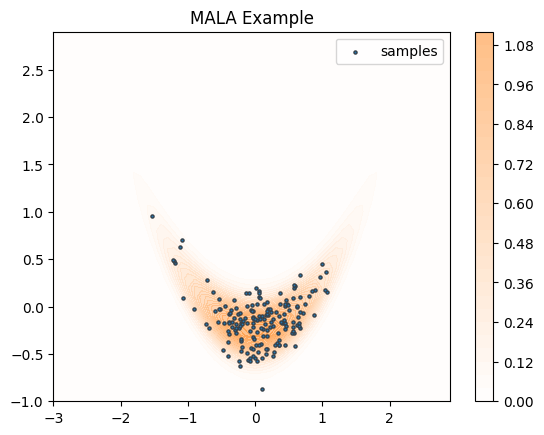

In [24]:
n_samples = 1000
h = 0.5
KEY, normal_key, uniform_key = random.split(KEY, 3)

normal_samples = random.normal(normal_key, (n_samples, 2))
u_samples = random.uniform(uniform_key, (n_samples, ))

grad_log_banana = jax.grad(log_banana_1d)
accepted_samples = []

x_cur = jnp.array([0., 0.])
for i in range(n_samples):
    x_prop = x_cur + (h**2) / 2 * grad_log_banana(x_cur) + h * normal_samples[i]

    log_p_cur = log_banana_1d(x_cur)
    log_p_prop = log_banana_1d(x_prop)
    log_q_cur = log_gaussian(x_cur, mean = x_prop + (h**2) / 2 * grad_log_banana(x_prop), cov = h**2 * jnp.eye(2))
    log_q_prop = log_gaussian(x_prop, mean = x_cur + (h**2) / 2 * grad_log_banana(x_cur), cov = h**2 * jnp.eye(2))

    log_alpha = jnp.minimum(0., log_p_prop - log_p_cur + log_q_cur - log_q_prop)

    if jnp.log(u_samples[i]) < log_alpha:
        x_cur = x_prop
        accepted_samples.append(x_cur)

accepted_samples = jnp.array(accepted_samples)

print(f"Acceptance rate: {len(accepted_samples) / n_samples:.2f}")

contour = plot_distribution(X1_banana, X2_banana, Z_banana, samples = accepted_samples, s = 5, title = "MALA Example")
plt.colorbar(contour)

## Step Size Experiment

Now let us see how the step size affects the sampling behaviour.

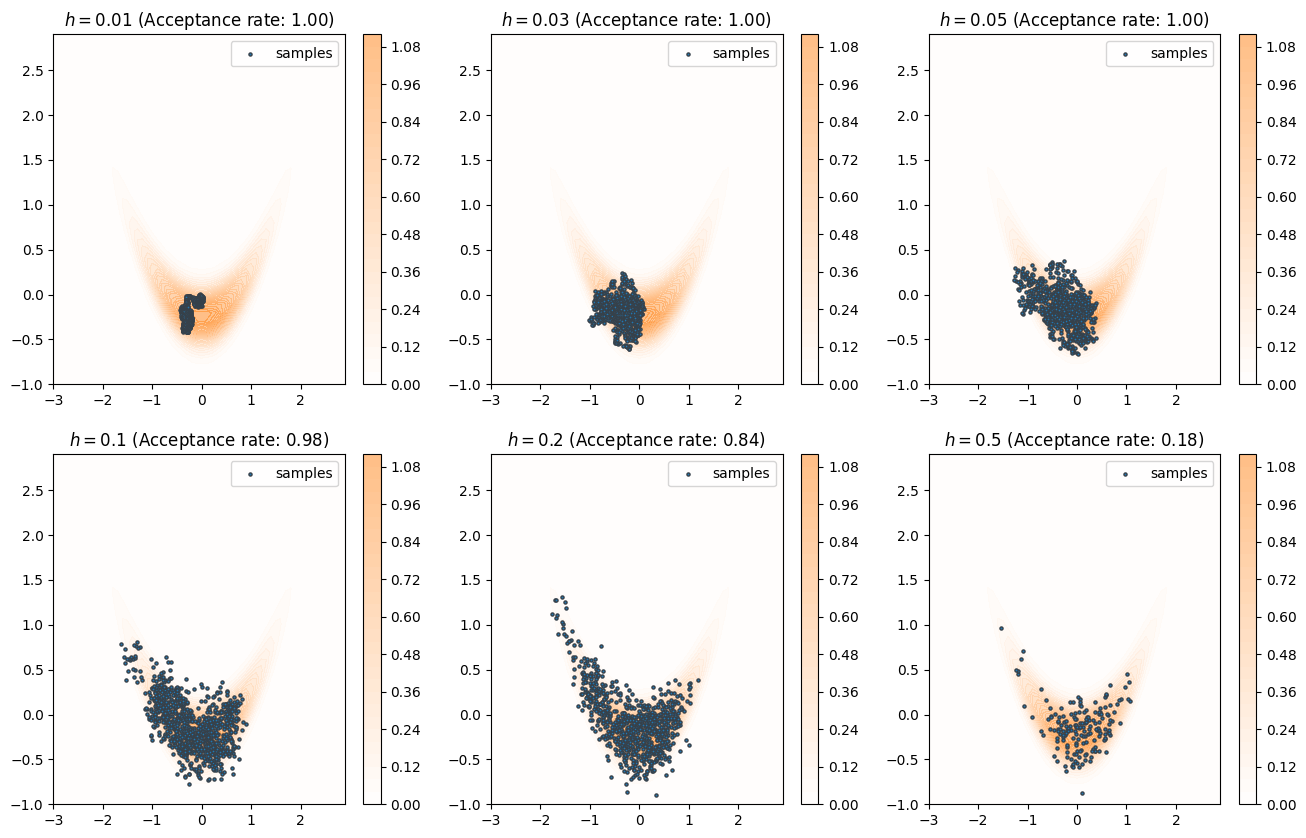

In [25]:
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (16, 10))
ax = axes.flatten()

for j, h in enumerate([0.01, 0.03, 0.05, 0.1, 0.2, 0.5]):
    accepted_samples = []

    x_cur = jnp.array([0., 0.])
    for i in range(n_samples):
        x_prop = x_cur + (h**2) / 2 * grad_log_banana(x_cur) + h * normal_samples[i]

        log_p_cur = log_banana_1d(x_cur)
        log_p_prop = log_banana_1d(x_prop)
        log_q_cur = log_gaussian(x_cur, mean = x_prop + (h**2) / 2 * grad_log_banana(x_prop), cov = h**2 * jnp.eye(2))
        log_q_prop = log_gaussian(x_prop, mean = x_cur + (h**2) / 2 * grad_log_banana(x_cur), cov = h**2 * jnp.eye(2))

        log_alpha = jnp.minimum(0., log_p_prop - log_p_cur + log_q_cur - log_q_prop)

        if jnp.log(u_samples[i]) < log_alpha:
            x_cur = x_prop
            accepted_samples.append(x_cur)

    accepted_samples = jnp.array(accepted_samples)

    contour = plot_distribution(X1_banana, X2_banana, Z_banana, 
                                samples = accepted_samples, s = 5, ax = ax[j],
                                title = fr"$h = {h}$ (Acceptance rate: {len(accepted_samples) / n_samples:.2f})")
    fig.colorbar(contour, ax = ax[j])

Small step sizes have very high acceptance but explore the banana slowly. Intermediate values around $h=0.1-0.2$ give much better coverage while keeping acceptance reasonably high. At $h=0.5$, the acceptance rate collapses and exploration becomes inefficient.

# Hamiltonian Monte Carlo

Hamiltonian Monte Carlo introduces auxiliary momentum variables and simulates Hamiltonian dynamics to generate distant proposals that approximately preserve the target density.

## Hamiltonian Augmentation

Dynamics of a moving object can be expressed in two variables: position and momentum. These variables allow us to calculate the potential and kinetic energy of the moving object, so that we can use the Law of Conservation of Energy.

Let us define an auxiliary momentum variable
$$ r \sim \mathcal{N}(0, M) $$
where $M$ is the mass matrix.

Let the joint distribution of $x$ and $r$ be
$$ p(x, r) \propto \exp \left[ -H(x, r) \right] $$
where $H$ is Hamiltonian
$$ H(x, r) = U(x) + K(r) $$
with
$$ U(x) = - \log p(x)\quad \text{potential energy} $$
$$ K(r) = \frac{1}{2} r^T M^{-1} r\quad \text{kinetic energy} $$

Therefore, the Hamiltonian is
$$ H(x, r) = -\log p(x) + \frac{1}{2} r^T M^{-1} r $$

Note that marginalizing the above on $r$ results in original target distribution $p(x)$, so we can sample from an augmented space $(x, r)$ and use only $x$.

## Hamiltonian Dynamics

Hamilton's equations are
$$ \frac{dx}{dt} = \frac{\partial H}{\partial r} $$
$$ \frac{dr}{dt} = -\frac{\partial H}{\partial x} $$

Using the Hamiltonian defined above we get
$$ \frac{dx}{dt} = M^{-1} r $$
and
$$ \frac{dr}{dt} = \nabla \log p(x) $$

The dynamics can be interpreted as:
* $r$ determines the direction and the speed of the motion
* the gradient of the density determines the direction towards which to move for $r$
* exact Hamiltonian dynamics preserve $H(x, r)$, so trajectories will remain on regions of same joint probability

## Leapfrog Integration

Exact Hamiltonian trajectories usually cannot be computed analytically, so we simulate them numerically using the **leapfrog integration**.

Let us have a step size $h$, then we make:
1. momentum half-step
$$ r_{t + 1/2} = r_t + \frac{h}{2} \nabla \log p(x_t) $$
2. position full step
$$ x_{t + 1} = x_t + hM^{-1} r_{t + 1/2} $$
3. second momentum half-step
$$ r_{t + 1} = r_{t + 1/2} + \frac{h}{2} \nabla \log p(x_{t+1}) $$
then we repeat the steps above $L$ times.

So one HMC iterations travels for the full integration time
$$ T = Lh $$

The key distinction with MALA is that
* MALA makes one step and accepts/rejects the proposal
* HMC makes bunch of mini-steps and only after them accepts/rejects the proposal

## Metropolis Correction

Since Leapfrog integration is approximate, the Hamiltonian dynamics are not preserved exactly.

Suppose we start from 
$$ (x, r) $$
and after $L$ leapfrog steps we get to
$$ (x', r') $$
that is our proposal.

We apply the Metropolis acceptance rule to this proposal:
$$ \alpha = \min (1, \exp [-H(x', r') + H(x, r)]) $$
or, equivalently,
$$ \log \alpha = \min (0, H(x, r) - H(x', r')) $$

When leapfrog preserves the Hamiltonian dynamics well, meaning
$$ H(x', r') \approx H(x, r) $$
the probability of accepting the proposal is
$$ \alpha \approx 1 $$

So, the one full iteration of HMC is
1. sample momentum $r \sim \mathcal{N}(0, M)$
2. simulate $L$ leapfrog steps
3. accept or reject
4. discard current momentum

## Banana Example

In our example let us use mass $M = I$.

Acceptance rate: 0.98


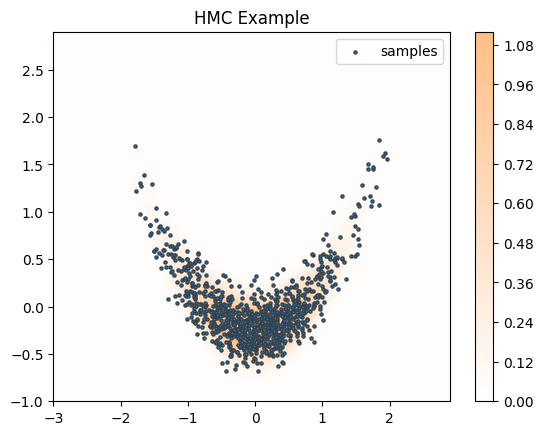

In [26]:
n_samples = 1000
h = 0.1
M = jnp.eye(2)
M_inv = jnp.linalg.inv(M)
L = 20

KEY, normal_key, uniform_key, momentum_key = random.split(KEY, 4)

normal_samples = random.normal(normal_key, (n_samples, 2))
momentum_raw_samples = random.normal(momentum_key, (n_samples, 2))
momentum_samples = momentum_raw_samples @ jnp.linalg.cholesky(M).T
u_samples = random.uniform(uniform_key, (n_samples, ))

def H(x, r):
    return -log_banana_1d(x) + 0.5 * r.T @ M_inv @ r

accepted_samples = []
x_cur = jnp.array([0., 0.])

for i in range(n_samples):
    r_cur = momentum_samples[i]
    x_prop = x_cur
    r_prop = r_cur

    for _ in range(L):
        r_prop += h/2 * grad_log_banana(x_prop)
        x_prop += h * M_inv @ r_prop
        r_prop += h/2 * grad_log_banana(x_prop)

    log_alpha = jnp.minimum(0.0, H(x_cur, r_cur) - H(x_prop, r_prop))
    if jnp.log(u_samples[i]) < log_alpha:
        x_cur = x_prop
        accepted_samples.append(x_prop)

accepted_samples = jnp.array(accepted_samples)

print(f"Acceptance rate: {len(accepted_samples) / n_samples:.2f}")

contour = plot_distribution(X1_banana, X2_banana, Z_banana, samples = accepted_samples, s = 5, title = "HMC Example")
plt.colorbar(contour)

HMC efficiently follows the curved banana geometry, producing good target coverage with a high acceptance rate.

# Comparison of MCMC Methods

We now compare Random-Walk Metropolis, MALA, and HMC on the same banana-shaped target in terms of sampling behavior, effective sample size, and computational efficiency.

## MH vs MALA vs HMC

**Random-Walk Metropolis**
$$ x' = x+\epsilon z, \qquad z\sim\mathcal N(0,I). $$
Uses no information about the target geometry.

**MALA**
$$ x' = x + \frac{h^2}{2}\nabla\log p(x) + hz. $$
Uses the local gradient to direct each proposal.

**HMC**

Introduces momentum and performs \(L\) leapfrog steps:
$$ (x,r) \longrightarrow (x',r'). $$
Uses a sequence of gradient evaluations to construct a longer trajectory.

In [27]:
def run_MH(normal_samples, u_samples, sigma_eps):
    n_samples = len(u_samples)

    full_chain = []
    num_accepted = 0

    x_cur = jnp.array([0., 0.])
    for i in range(n_samples):
        x_prop = x_cur + normal_samples[i] * sigma_eps

        log_p = log_banana_1d(x_prop)
        log_q = log_banana_1d(x_cur)

        log_alpha = jnp.minimum(0, log_p - log_q)
        if jnp.log(u_samples[i]) < log_alpha:
            x_cur = x_prop
            num_accepted += 1

        full_chain.append(x_cur)

    return jnp.array(full_chain), num_accepted / n_samples

def run_MALA(normal_samples, u_samples, h):
    n_samples = len(u_samples)

    full_chain = []
    num_accepted = 0

    x_cur = jnp.array([0., 0.])
    for i in range(n_samples):
        x_prop = x_cur + (h**2) / 2 * grad_log_banana(x_cur) + h * normal_samples[i]

        log_p_cur = log_banana_1d(x_cur)
        log_p_prop = log_banana_1d(x_prop)
        log_q_cur = log_gaussian(x_cur, mean = x_prop + (h**2) / 2 * grad_log_banana(x_prop), cov = h**2 * jnp.eye(2))
        log_q_prop = log_gaussian(x_prop, mean = x_cur + (h**2) / 2 * grad_log_banana(x_cur), cov = h**2 * jnp.eye(2))

        log_alpha = jnp.minimum(0., log_p_prop - log_p_cur + log_q_cur - log_q_prop)

        if jnp.log(u_samples[i]) < log_alpha:
            x_cur = x_prop
            num_accepted += 1

        full_chain.append(x_cur)

    return jnp.array(full_chain), num_accepted / n_samples

def run_HMC(normal_samples, momentum_samples, u_samples, h, L, M_inv):
    def H(x, r):
        return -log_banana_1d(x) + 0.5 * r.T @ M_inv @ r

    n_samples = len(u_samples)

    full_chain = []
    num_accepted = 0

    x_cur = jnp.array([0., 0.])

    for i in range(n_samples):
        r_cur = momentum_samples[i]
        x_prop = x_cur
        r_prop = r_cur

        for _ in range(L):
            r_prop += h/2 * grad_log_banana(x_prop)
            x_prop += h * M_inv @ r_prop
            r_prop += h/2 * grad_log_banana(x_prop)

        log_alpha = jnp.minimum(0.0, H(x_cur, r_cur) - H(x_prop, r_prop))
        if jnp.log(u_samples[i]) < log_alpha:
            x_cur = x_prop
            num_accepted += 1

        full_chain.append(x_cur)
    
    return jnp.array(full_chain), num_accepted / n_samples

In [28]:
n_samples = 1000

sigma_eps = 0.5          # MH
h_mala = 0.5             # MALA
h_hmc = 0.1              # HMC
L = 20

M = jnp.eye(2)
M_inv = jnp.linalg.inv(M)
L = 20

KEY, normal_key, uniform_key, momentum_key = random.split(KEY, 4)

normal_samples = random.normal(normal_key, (n_samples, 2))
momentum_raw_samples = random.normal(momentum_key, (n_samples, 2))
momentum_samples = momentum_raw_samples @ jnp.linalg.cholesky(M).T
u_samples = random.uniform(uniform_key, (n_samples, ))

# ======== MH ========
MH_samples, MH_acceptance = run_MH(normal_samples, u_samples, sigma_eps)
jax.block_until_ready(MH_samples)

start = time.perf_counter()
MH_samples, MH_acceptance = run_MH(normal_samples, u_samples, sigma_eps)
jax.block_until_ready(MH_samples)
MH_runtime = time.perf_counter() - start

# ======== MALA ========
MALA_samples, MALA_acceptance = run_MALA(normal_samples, u_samples, h_mala)
jax.block_until_ready(MALA_samples)

start = time.perf_counter()
MALA_samples, MALA_acceptance = run_MALA(normal_samples, u_samples, h_mala)
jax.block_until_ready(MALA_samples)
MALA_runtime = time.perf_counter() - start

# ======== HMC ========
HMC_samples, HMC_acceptance = run_HMC(normal_samples, momentum_samples, u_samples, h_hmc, L, M_inv)
jax.block_until_ready(HMC_samples)

start = time.perf_counter()
HMC_samples, HMC_acceptance = run_HMC(normal_samples, momentum_samples, u_samples, h_hmc, L, M_inv)
jax.block_until_ready(HMC_samples)
HMC_runtime = time.perf_counter() - start

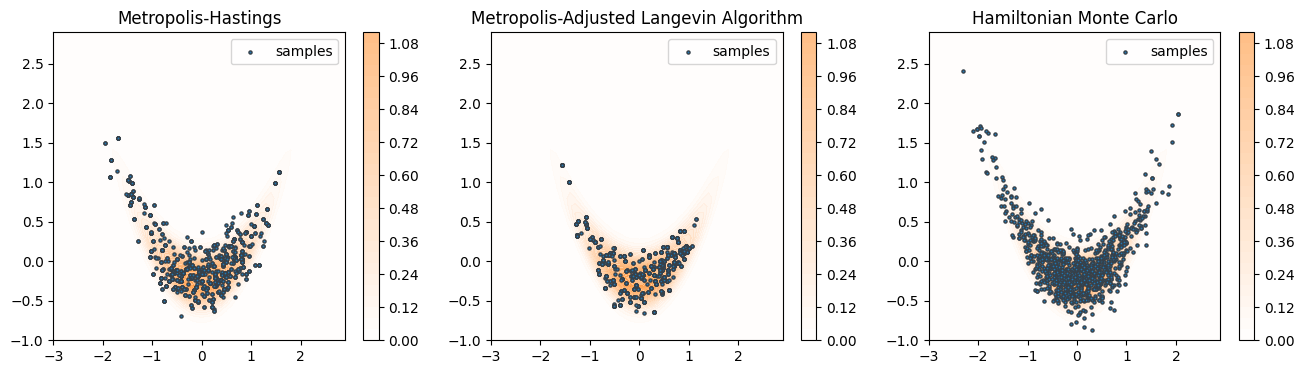

In [29]:
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (16, 4))

plot_distribution(X1_banana, X2_banana, Z_banana, samples = MH_samples, ax = axes[0], s = 5, title = "Metropolis-Hastings")
plot_distribution(X1_banana, X2_banana, Z_banana, samples = MALA_samples, ax = axes[1], s = 5, title = "Metropolis-Adjusted Langevin Algorithm")
contour = plot_distribution(X1_banana, X2_banana, Z_banana, samples = HMC_samples, ax = axes[2], s = 5, title = "Hamiltonian Monte Carlo")
fig.colorbar(contour, ax = axes[0])
fig.colorbar(contour, ax = axes[1])
fig.colorbar(contour, ax = axes[2])

## ESS

In [30]:
results = []

for method, samples, acceptance in [
    ("MH", MH_samples, MH_acceptance),
    ("MALA", MALA_samples, MALA_acceptance),
    ("HMC", HMC_samples, HMC_acceptance),
]:
    ess_values, relative_ess = ess(samples)

    results.append({
        "Method": method,
        "Acceptance": acceptance,
        "ESS_x0": ess_values[0],
        "ESS_x1": ess_values[1],
        "Relative ESS_x0": relative_ess[0],
        "Relative ESS_x1": relative_ess[1],
    })


df = pd.DataFrame(results)

df.style.format({
    "Acceptance": "{:.2%}",
    "ESS_x0": "{:.1f}",
    "ESS_x1": "{:.1f}",
    "Relative ESS_x0": "{:.2f}",
    "Relative ESS_x1": "{:.2f}",
})

,Method,Acceptance,ESS_x0,ESS_x1,Relative ESS_x0,Relative ESS_x1
0,MH,33.40%,19.2,32.5,0.02,0.03
1,MALA,20.00%,25.2,30.6,0.03,0.03
2,HMC,98.00%,1000.0,363.5,1.00,0.36


## Runtime and ESS per Second

In [31]:
results = []

for method, samples, runtime in [
    ("MH", MH_samples, MH_runtime),
    ("MALA", MALA_samples, MALA_runtime),
    ("HMC", HMC_samples, HMC_runtime),
]:
    ess_values, _ = ess(samples)

    results.append({
        "Method": method,
        "Runtime (sec)": runtime,
        "ESS/s_x0": ess_values[0] / runtime,
        "ESS/s_x1": ess_values[1] / runtime,
    })


df = pd.DataFrame(results)

df.style.format({
    "Runtime (sec)": "{:.3f}",
    "ESS/s_x0": "{:.1f}",
    "ESS/s_x1": "{:.1f}",
})

,Method,Runtime (sec),ESS/s_x0,ESS/s_x1
0,MH,1.620,11.9,20.0
1,MALA,42.143,0.6,0.7
2,HMC,488.759,2.0,0.7


HMC gives by far the best mixing and sample quality, with much higher ESS and excellent coverage of the banana target. However, it is also dramatically more expensive computationally, so MH achieves the highest ESS per second in this implementation, while MALA lies between the two.

# Limitations and Practical Considerations

Sampling methods can be sensitive to proposal choice, step size, initialization, and target geometry. In higher dimensions, poor tuning may lead to slow mixing, low ESS, or high computational cost. Diagnostics are therefore an important part of practical MCMC.

# Further Methods

More advanced methods include Gibbs sampling, adaptive MCMC, slice sampling, Sequential Monte Carlo, and No-U-Turn Sampling (NUTS). These methods can improve robustness or reduce manual tuning for more complex targets.

# Conclusion

Sampling provides a general way to approximate expectations when direct integration is difficult. Direct sampling, rejection sampling, importance sampling, MH, MALA, and HMC offer different trade-offs between simplicity, efficiency, and computational cost.